In [41]:
#--------------------------------------------------------------------------------------------------------------------------
#               NETFLIX & GAMESTOP FINANCIAL DASHBOARD ANALYSIS
#--------------------------------------------------------------------------------------------------------------------------


This program aims to create interactive dashboards to visualize the stock performance and revenue data for two prominent companies: GameStop and Netflix. We will be utilizing Plotly for the GameStop dashboard and PowerBI for the Netflix dashboard to provide comprehensive insights into their financial health and market trends.

In [42]:
#Importing the required modules

import pandas as pd
import yfinance as yf # A Python library for downloading historical market data from Yahoo! Finance
from bs4 import BeautifulSoup # To parse the html data.
import requests # To get the data from the URL.


In [43]:
# --------------------------------------------------------------
#     GAMESTOP STOCK DATA USING yfinance API
# --------------------------------------------------------------

gme=yf.Ticker("GME")

# -------------------------------
# CREATE DATASET USING hisotry()
# -------------------------------

gme_data=gme.history(period='max')
gme_data.reset_index(inplace=True)
#reset the index

gme_data=gme_data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
# Now the dataset contain the Date, High, Low, Close, Volume data only..

gme_data['Date']=pd.to_datetime(gme_data['Date'])
print(gme_data.tail()) # We have 6094 rows in the gme stock data

# -------------------------------
#  SAVE DATASET AS CSV FILE
# -------------------------------
gme_data.to_csv("gme_stock.csv",index=False)

                          Date       Open       High        Low      Close  \
6091 2026-04-30 00:00:00-04:00  24.360001  25.080000  24.209999  24.950001   
6092 2026-05-01 00:00:00-04:00  24.850000  26.879999  24.850000  26.530001   
6093 2026-05-04 00:00:00-04:00  25.110001  26.150000  23.670000  23.840000   
6094 2026-05-05 00:00:00-04:00  23.209999  24.730000  22.850000  24.230000   
6095 2026-05-06 00:00:00-04:00  24.299999  25.440001  23.959999  25.170000   

        Volume  
6091   4492500  
6092  20284900  
6093  40178600  
6094  17979600  
6095  11569700  


In [44]:
# --------------------------------------------------------------
#      GameStop REVENUE DATA RETREIVAL USING WEB SCRAPPING
# --------------------------------------------------------------

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

tables = pd.read_html(url)

# Check tables
print(len(tables))

# Usually GameStop revenue is in one of the tables
gme_revenue = tables[1]   # adjust if needed

print(gme_revenue.head())
gme_revenue.columns = ["Date", "Revenue"]

# Remove $ and commas
gme_revenue["Revenue"] = gme_revenue["Revenue"].astype(str)
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace("$", "", regex=False)
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(",", "", regex=False)

# Remove empty rows
gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]

# Convert types
gme_revenue["Revenue"] = gme_revenue["Revenue"].astype(float)
gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
gme_revenue.to_csv("gme_revenue.csv",index=False)

6
  GameStop Quarterly Revenue (Millions of US $)  \
0                                    2020-04-30   
1                                    2020-01-31   
2                                    2019-10-31   
3                                    2019-07-31   
4                                    2019-04-30   

  GameStop Quarterly Revenue (Millions of US $).1  
0                                          $1,021  
1                                          $2,194  
2                                          $1,439  
3                                          $1,286  
4                                          $1,548  


In [45]:
# --------------------------------------------------------------
#      DATA VISUALISATION USING PLOTLY
# --------------------------------------------------------------

#Features of the dashboard:
#candlestick
#Volumne bars
#Revenue comparison (Secondary axis)
#Range selector (6m, 1y, 5y)
#hover+zoom+toggle

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# -------------------------------
# LOAD DATA
# -------------------------------
gme_data = pd.read_csv("gme_stock.csv")
gme_revenue = pd.read_csv("gme_revenue.csv")

# Convert Date
gme_data['Date'] = pd.to_datetime(gme_data['Date'], utc=True).dt.tz_localize(None)
gme_revenue['Date'] = pd.to_datetime(gme_revenue['Date'], utc=True).dt.tz_localize(None)

# Sort
gme_data = gme_data.sort_values("Date")
gme_revenue = gme_revenue.sort_values("Date")

# -------------------------------
# CREATE ADVANCED SUBPLOTS
# -------------------------------
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    specs=[[{"secondary_y": True}], [{}]],
    subplot_titles=("Stock Price + Revenue", "Trading Volume")
)

# Candlestick (PRO)
fig.add_trace(go.Candlestick(
    x=gme_data['Date'],
    open=gme_data['Open'],
    high=gme_data['High'],
    low=gme_data['Low'],
    close=gme_data['Close'],
    name="Stock Price"
), row=1, col=1, secondary_y=False)

#  Revenue (secondary axis)
fig.add_trace(go.Scatter(
    x=gme_revenue['Date'],
    y=gme_revenue['Revenue'],
    mode='lines+markers',
    name='Revenue',
    line=dict(width=3, dash='dot')
), row=1, col=1, secondary_y=True)

#  Volume bars
fig.add_trace(go.Bar(
    x=gme_data['Date'],
    y=gme_data['Volume'],
    name='Volume',
    opacity=0.5
), row=2, col=1)

# -------------------------------
# LAYOUT MAGIC
# -------------------------------
fig.update_layout(
    title=" GameStop Advanced Interactive Dashboard",
    height=850,
    hovermode="x unified",
    template="plotly_dark",   #  Dark theme (looks premium)

    # Range selector
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=5, label="5Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

# Axis labels
fig.update_yaxes(title_text="Stock Price", secondary_y=False)
fig.update_yaxes(title_text="Revenue", secondary_y=True)

# -------------------------------
# SHOW + SAVE
# -------------------------------
fig.show()

#  Save as interactive HTML (VERY IMPORTANT)
fig.write_html("gme_dashboard.html")

In [46]:
# --------------------------------------------------------------
#          NETFLIX STOCK DATA USING yfinance API
# --------------------------------------------------------------

netflix=yf.Ticker('NFLX')
netflix_data=netflix.history(period='max')
netflix_data.reset_index(inplace=True)

netflix_data=netflix_data[['Date','Open','High','Low','Close','Volume']]
# Now the dataset contain the Date, High, Low, Close, Volume data only..

netflix_data['Date']=pd.to_datetime(netflix_data['Date'])
print(netflix_data.tail()) #We have 6025 rows in the netflix stock data

# -------------------------------
#    SAVE DATA AS CSV FILE
# -------------------------------

netflix_data.to_csv("netflix_stock.csv",index=False)


                          Date       Open       High        Low      Close  \
6022 2026-04-30 00:00:00-04:00  91.349998  94.220001  90.769997  93.610001   
6023 2026-05-01 00:00:00-04:00  94.419998  94.699997  91.900002  92.059998   
6024 2026-05-04 00:00:00-04:00  92.099998  92.330002  90.889999  91.019997   
6025 2026-05-05 00:00:00-04:00  91.180000  91.279999  87.570000  87.889999   
6026 2026-05-06 00:00:00-04:00  87.150002  88.550003  86.720001  88.269997   

        Volume  
6022  40923000  
6023  30406900  
6024  25928800  
6025  51961300  
6026  41869800  


In [47]:
# -------------------------------------------------------------------------------------------------------------------------
#----------------------REVENUE DATA OF NETFLIX USING WEB SCRAPPING--------------------------------------------
# -------------------------------------------------------------------------------------------------------------------------

# URL for Netflix revenue
url = "https://www.macrotrends.net/stocks/charts/NFLX/netflix/revenue"

# Headers to avoid 403
headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

# Send request
response = requests.get(url, headers=headers)

# Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# Find all tables
tables = soup.find_all("table")

print("Number of tables found:", len(tables))  # Debug

# Pick correct table safely
target_table = None
for table in tables:
    if "Revenue" in str(table):
        target_table = table
        break

# Create dataframe, initialize as empty
netflix_revenue = pd.DataFrame(columns=["Date", "Revenue"])

if target_table: # Check if target_table was found
    # Extract rows safely
    for row in target_table.tbody.find_all("tr"):
        cols = row.find_all("td")

        if len(cols) < 2:
            continue

        date = cols[0].text.strip()
        revenue = cols[1].text.strip()

        netflix_revenue.loc[len(netflix_revenue)] = [date, revenue]

    # Clean revenue
    netflix_revenue["Revenue"] = netflix_revenue["Revenue"].str.replace(",", "", regex=False)
    netflix_revenue["Revenue"] = netflix_revenue["Revenue"].str.replace("$", "", regex=False)

    # Remove empty rows
    netflix_revenue = netflix_revenue[netflix_revenue["Revenue"] != ""]

    # Convert types
    if not netflix_revenue.empty: # Only convert if there's data after cleaning
        netflix_revenue["Revenue"] = netflix_revenue["Revenue"].astype(float)
        netflix_revenue["Date"] = pd.to_datetime(netflix_revenue["Date"])

    # Sort
    netflix_revenue = netflix_revenue.sort_values(by="Date")

    print(netflix_revenue.head())
else:
    print("Warning: Expected revenue table not found in the scraped content for Netflix.")
    print("Initializing netflix_revenue as an empty DataFrame.")


Number of tables found: 0
Initializing netflix_revenue as an empty DataFrame.


In [48]:
print(gme_revenue.head()) #Empty dataframe created
print(netflix_revenue.head()) #Empty dataframe created

         Date  Revenue
61 2005-01-31    709.0
60 2005-04-30    475.0
59 2005-07-31    416.0
58 2005-10-31    534.0
57 2006-01-31   1667.0
Empty DataFrame
Columns: [Date, Revenue]
Index: []


In [49]:
#-------------------------------------------------------------------------------------------------
#Code to obtain the Netflix revenue data using yfinance (if the web scrapping is not working)
#-------------------------------------------------------------------------------------------------

#-----------------------------------
# LOAD NETFLIX DATA
#-----------------------------------

netflix = yf.Ticker("NFLX")

# Get quarterly financial data
quarterly_financials = netflix.quarterly_financials
# Transpose data (dates become rows)
quarterly_financials = quarterly_financials.T
# Reset index
quarterly_financials.reset_index(inplace=True)
# Rename columns
quarterly_financials.rename(columns={"index": "Date"}, inplace=True)

#-----------------------------------
# EXTRACT REVENUE
#-----------------------------------

# Check available columns
print(quarterly_financials.columns)
# Extract Total Revenue
netflix_revenue = quarterly_financials[['Date', 'Total Revenue']]
# Rename column
netflix_revenue.rename(columns={"Total Revenue": "Revenue"}, inplace=True)


#-----------------------------------
#  DATA CLEANING
#-----------------------------------

#Drop all the duplicate values
netflix_revenue=netflix_revenue.drop_duplicates()
#Drop all the NaN values
netflix_revenue=netflix_revenue.dropna()

#Remove empty space
netflix_revenue = netflix_revenue[netflix_revenue['Revenue'].astype(str).str.strip() != ""]
#Convert Revenue into float
netflix_revenue['Revenue'] = netflix_revenue['Revenue'].astype(float)
#formatting of date using to_datetime()
netflix_revenue['Date'] = pd.to_datetime(netflix_revenue['Date'],utc=True).dt.tz_localize(None)
#Sort the data
netflix_revenue = netflix_revenue.sort_values(by='Date')
#Reset index
netflix_revenue.reset_index(drop=True, inplace=True)
print(netflix_revenue)

#-----------------------------------
# SAVE CSV
#-----------------------------------

netflix_revenue.to_csv("netflix_revenue.csv", index=False)

Index(['Date', 'Tax Effect Of Unusual Items', 'Tax Rate For Calcs',
       'Normalized EBITDA',
       'Net Income From Continuing Operation Net Minority Interest',
       'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA',
       'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income',
       'Normalized Income',
       'Net Income From Continuing And Discontinued Operation',
       'Total Expenses', 'Total Operating Income As Reported',
       'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS',
       'Basic EPS', 'Diluted NI Availto Com Stockholders',
       'Net Income Common Stockholders', 'Net Income',
       'Net Income Including Noncontrolling Interests',
       'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income',
       'Net Non Operating Interest Income Expense',
       'Interest Expense Non Operating', 'Interest Income Non Operating',
       'Operating Income', 'Operating Expense', 'Research And Development',
       '

/tmp/ipykernel_5047/2335323167.py:29: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [50]:
#---------------------------------------------------------------------------------------------------------
#                   DATA VISUALISATION (NETFLIX STOCK AND REVENUE)
#---------------------------------------------------------------------------------------------------------

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# LOAD DATA
# -------------------------------

nflx_stock = pd.read_csv("netflix_stock.csv")
nflx_revenue = pd.read_csv("netflix_revenue.csv")

# -------------------------------
# CLEAN DATA
# -------------------------------

nflx_stock['Date'] = pd.to_datetime(
    nflx_stock['Date'],
    utc=True
).dt.tz_localize(None)

nflx_revenue['Date'] = pd.to_datetime(
    nflx_revenue['Date']
)

# -------------------------------
# MOVING AVERAGE
# -------------------------------

nflx_stock['MA_30'] = nflx_stock['Close'].rolling(30).mean()

# -------------------------------
# CREATE INTERACTIVE SUBPLOTS
# -------------------------------

fig = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=(
        "Netflix Stock Price + Moving Average",
        "Netflix Revenue Growth",
        "Trading Volume"
    )
)

# -------------------------------
# STOCK PRICE
# -------------------------------

fig.add_trace(
    go.Scatter(
        x=nflx_stock['Date'],
        y=nflx_stock['Close'],
        mode='lines',
        name='Stock Price',
        line=dict(width=2)
    ),
    row=1,
    col=1
)

# -------------------------------
# MOVING AVERAGE
# -------------------------------

fig.add_trace(
    go.Scatter(
        x=nflx_stock['Date'],
        y=nflx_stock['MA_30'],
        mode='lines',
        name='30-Day MA',
        line=dict(dash='dot')
    ),
    row=1,
    col=1
)

# -------------------------------
# REVENUE
# -------------------------------

fig.add_trace(
    go.Scatter(
        x=nflx_revenue['Date'],
        y=nflx_revenue['Revenue'],
        mode='lines+markers',
        name='Revenue'
    ),
    row=2,
    col=1
)

# -------------------------------
# VOLUME
# -------------------------------

fig.add_trace(
    go.Bar(
        x=nflx_stock['Date'],
        y=nflx_stock['Volume'],
        name='Volume',
        opacity=0.5
    ),
    row=3,
    col=1
)

# -------------------------------
# LAYOUT
# -------------------------------

fig.update_layout(
    title=" Netflix Interactive Dashboard",
    height=900,
    hovermode='x unified',
    template='plotly_dark'
)

fig.show()

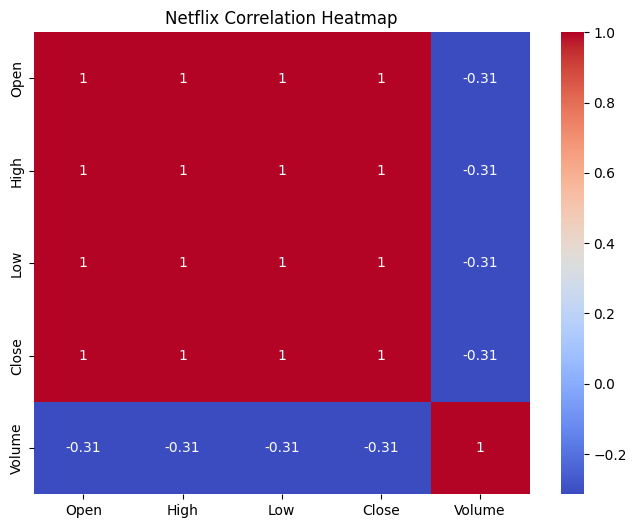

In [51]:
correlation = nflx_stock[
    ['Open', 'High', 'Low', 'Close', 'Volume']
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title("Netflix Correlation Heatmap")

plt.show()

In [52]:
#---------------------------------------------------------------------------------------------------------
#                    INSIGHTS (GameStop)
#---------------------------------------------------------------------------------------------------------

#Extreme stock volatility: GameStop prices fluctuate sharply within short period of time.
# This indicates the following :
      # a) unstable market behaviour
      # b) Unpredictable rise and fall
      # c) investors shift in risk perception

# Sudden price spike:
    # Dashboard shows dramatic upward spike in stock price due to:
            # Retail investors behavior
            # Meme stock phenomena and social media influence
            # Short squeeze events

#Unpredictable market behaviour: highly unpredictable and emotionally driven

# Revenue trend graph
   # Despite of stock price fluctuations, revenue changes are comparatively moderate
   #This infers that:
        # Revenue doesnot increase proportionately with the stock spikes
        # Investors speculations have greater role in the market than the company
        # Increasing competition from digital gaming platforms
        # Changing consumer behaviour

# Daily return graph says "Massive daily price swings"
     #This interprets that GameStop experienced speculative momentum amongst the consumer and investors
# Volume spikes often align with: rapid price increase, and sudden market crashes





In [53]:
#---------------------------------------------------------------------------------------------------------
#                    INSIGHTS (Netflix stocks)
#---------------------------------------------------------------------------------------------------------

#The stock price generally shows upward trend indicating,
             # a) Strong market positioning
             # b) Successful business growth
             # c) Attracting investors

#Short term fluctuations due to:
            # a) Competition in streaming industry
            # b) Subscriber growth announcement
            # c) Overall market condition

# Interpretation
      # a) When stock price remains above moving average- BULLISH momentum
      # b) When stock price falls below moving average-temporary BEARISH trend


# Steady growth in stock price reflects POSITIVE investors sentiments and varies directly with the revenue growth of the NETFLIX

#---------------------------------------------------------------------------------------------------------
#                    INSIGHTS (Netflix revenue)
#---------------------------------------------------------------------------------------------------------

# Consistent revenue growth: revenue increases steadily
# This suggests that the subsription model is successful,
# thereby growing subscription count, and commercial expansion

#Stable business performance
# Financial stability and predictable growth

#Trade volume graphs says high volume during major events (like, major product/content launch, earning announcements etc.)
#Interpretation:
           #high volume + rising price → bullish market confidence
           #high volume + falling price → market uncertainty or negative sentiment

#Correlation Heatmap//
              # Open, High, Low, and Close prices are directly correlated.
              # If one price metric rises, others generally rise as well (stable market).
              # Trading volume may not always strongly corelate with the stock prices.


